In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from grad_cam import skull_strip
from SabreNet import build_model
from scipy.ndimage import distance_transform_edt
import tensorflow as tf
from tensorflow.keras.models import Model

C:\Users\Lucifer\AppData\Roaming\Python\Python310\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.2.0)/charset_normalizer (3.4.5) doesn't match a supported version!
  warnings.warn(


In [2]:
lab = {'glioma' : 0, 'meningioma' : 1, 'pituitary' : 2}
rev_lab = dict(zip(lab.values(), lab.keys()))
img_size = 224

In [3]:
model = build_model(input_shape=(224,224,1), num_classes=3)

In [4]:
model.load_weights('BT_CLF_Attention.h5')

In [5]:
def make_random_donut(
    shape=(224, 224, 1),
    outer_radius_range=(35, 60),
    inner_radius_range=(12, 28),
    center_jitter=50,
    position=None,
    value=1.0,
    background=0.0,
    dtype=np.float32,
):
    """
    Create a random donut mask with shape (H, W, 1).

    Parameters
    ----------
    shape : tuple
        Output shape, expected as (H, W, 1).
    outer_radius_range : tuple
        Min and max outer radius.
    inner_radius_range : tuple
        Min and max inner radius.
    center_jitter : int
        Max random shift from image center in pixels. Used only when position is None.
    position : tuple, str, or None
        Donut center position.

        - None: randomly jitter around image center.
        - (cx, cy): explicit donut center in pixel coordinates.
        - "center": place donut at image center.

    value : float
        Pixel value for the donut.
    background : float
        Pixel value for the background.
    dtype : numpy dtype
        Output dtype.

    Returns
    -------
    img : np.ndarray
        Donut image of shape (H, W, 1).
    """

    H, W, C = shape
    assert C == 1, "Shape must be (H, W, 1)"

    img = np.full((H, W), background, dtype=dtype)

    # Random radii
    outer_r = np.random.randint(*outer_radius_range)
    inner_r = np.random.randint(*inner_radius_range)

    # Make sure inner radius is smaller than outer radius
    inner_r = min(inner_r, outer_r - 5)

    # Choose donut center
    if position is None:
        # Random center around the image center
        cx = W // 2 + np.random.randint(-center_jitter, center_jitter + 1)
        cy = H // 2 + np.random.randint(-center_jitter, center_jitter + 1)

    elif position == "center":
        cx = W // 2
        cy = H // 2

    else:
        # Explicit position as (cx, cy)
        cx, cy = position

    # Safety clamp so the donut mostly stays inside the image
    margin = outer_r + 1
    cx = int(np.clip(cx, margin, W - margin - 1))
    cy = int(np.clip(cy, margin, H - margin - 1))

    y, x = np.ogrid[:H, :W]
    dist_sq = (x - cx) ** 2 + (y - cy) ** 2

    donut = (dist_sq <= outer_r ** 2) & (dist_sq >= inner_r ** 2)

    img[donut] = value

    return img[..., None]

In [6]:
def predict(img, gt_mask, gt_cls):

    gt_cls = rev_lab.get(gt_cls)

    print("GT: ", gt_cls)

    res = model.predict(np.expand_dims(img, 0), verbose=False)
    print(f"Pred: {rev_lab.get(np.argmax(res[1]))} ({np.max(res[1])})")

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    axes[0].imshow(img, cmap='gray')
    axes[0].set_title("Input")
    axes[0].axis("off")

    axes[1].imshow(gt_mask, cmap='gray')
    axes[1].set_title("Ground Truth")
    axes[1].axis("off")

    axes[2].imshow(res[0][0])
    axes[2].set_title("Prediction")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

names = {
        "conv2d_88":   "Shallow CNN Features",
        "conv_block_7": "Encoder Block 1 (Low-level)",
        "conv_block_8": "Encoder Block 2 (Texture)",
        "conv_block_9": "Encoder Block 3 (High-level)",
        "conv_block_10": "Encoder Block 4 (Semantic)",
        "conv_block_11": "Decoder Block 1 (Fusion)",
        "conv_block_12": "Decoder Block 2 (Upsampling)",
        "conv_block_13": "Decoder Block 3 (Localization)",
        "mask_pred":    "Final Prediction",
    }

def overlay_mask_on_image(base_img, mask, color=(255, 0, 0), alpha=0.5):
    """Overlay segmentation mask (binary or soft) on grayscale image."""
    mask = np.array(mask, dtype=np.float32)
    if mask.ndim == 3:
        mask = mask[:, :, 0]

    base = (base_img * 255).astype(np.uint8) if base_img.max() <= 1.0 else base_img.astype(np.uint8)
    if base.ndim == 2:
        base = cv2.cvtColor(base, cv2.COLOR_GRAY2BGR)
    elif base.shape[-1] == 1:
        base = cv2.cvtColor(base[..., 0], cv2.COLOR_GRAY2BGR)

    mask = cv2.resize(mask, (base.shape[1], base.shape[0]), interpolation=cv2.INTER_LINEAR)
    mask = np.clip(mask, 0.0, 1.0)

    mask_colored = np.zeros_like(base, dtype=np.uint8)
    mask_colored[:, :, 0] = color[0]
    mask_colored[:, :, 1] = color[1]
    mask_colored[:, :, 2] = color[2]

    overlay = cv2.addWeighted(base, 1 - alpha, mask_colored, alpha, 0)
    overlay = np.where(mask[..., None] > 0.5, overlay, base)
    overlay = cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)
    return overlay

def seg_gradcam_for_layer(model, img_array, layer_name):
    """
    Layer-wise Grad-CAM for segmentation head.
    Backprop from mask_pred to given layer.
    """
    grad_model = Model(
        inputs=model.inputs,
        outputs=[model.get_layer(layer_name).output,
                 model.get_layer("mask_pred").output]
    )

    with tf.GradientTape() as tape:
        feats, mask_out = grad_model(img_array, training=False)
        # scalar loss: mean log probability of predicted mask
        loss = tf.reduce_mean(tf.math.log(mask_out + 1e-6))

    grads = tape.gradient(loss, feats)
    if grads is None:
        raise ValueError(f"Gradients are None for layer {layer_name}")

    # Global average pooling over spatial dims
    weights = tf.reduce_mean(grads[0], axis=(0, 1))         # (C,)
    cam = tf.reduce_sum(feats[0] * weights, axis=-1)        # (H,W)
    cam = np.maximum(cam, 0)
    cam /= (cam.max() + 1e-8)
    return cam

def plot_layer_gradcam(base_img, cam, layer_name):
    # Resize CAM to input size
    cam_resized = cv2.resize(cam, (base_img.shape[1], base_img.shape[0]), interpolation=cv2.INTER_LINEAR)
    heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)

    base = (base_img * 255).astype(np.uint8) if base_img.max() <= 1.0 else base_img.astype(np.uint8)
    if base.ndim == 2:
        base = cv2.cvtColor(base, cv2.COLOR_GRAY2BGR)
    elif base.shape[-1] == 1:
        base = cv2.cvtColor(base[..., 0], cv2.COLOR_GRAY2BGR)

    overlayed = cv2.addWeighted(base, 0.5, heatmap, 0.5, 0)
    overlayed = cv2.cvtColor(overlayed, cv2.COLOR_BGR2RGB)


    return overlayed

    plt.figure(figsize=(6, 6))
    plt.imshow(overlayed)
    plt.title(f"{names.get(layer_name, layer_name)}")
    plt.axis("off")
    plt.show()

def plot_gradcam(img, model):
    
    feature_layers = [
    l for l in model.layers
    if hasattr(l, "output_shape")
    and len(l.output_shape) == 4
    and ("block" in l.name or "reshape_back" in l.name)
    ]

    layers = [l.name for l in feature_layers]
    
    for lname in layers:
        names.setdefault(lname, lname)

    if any(l.name == "mask_pred" for l in model.layers):
        layers.append("mask_pred")

    layers = list(dict.fromkeys(layers))
    
    img_org = img.copy()
    img = skull_strip(img)
    # img = cv2.resize(img, (224, 224))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)/255
    img = np.expand_dims(img, -1)
    Xb = np.expand_dims(img, 0)
    img = np.squeeze(img)

    # Dual-output model: (mask_pred, cls_pred)
    mask_pred, cls_pred = model.predict(Xb, verbose=0)
    mask_pred = np.array(mask_pred[0, :, :, 0], dtype=np.float32)
    cls_pred = np.array(cls_pred[0], dtype=np.float32)

    # cls_label = int(np.argmax(cls_pred))
    # cls_prob = float(np.max(cls_pred))

    # overlay_img = overlay_mask_on_image(img_org, mask_pred, color=(255, 0, 0), alpha=0.5)
    # plt.figure(figsize=(6, 6))
    # plt.imshow(overlay_img)
    # plt.title(f"Predicted Tumor Region (Class {cls_label}, p={cls_prob:.2f})")
    # plt.axis("off")
    # plt.show()

    grads = []
    for layer_name in layers:
        try:
            if layer_name != "up4_mhsa_reshape_back":
                continue

            print(f"🔍 Computing Seg-Grad-CAM for layer: {layer_name}")
            cam = seg_gradcam_for_layer(model, Xb, layer_name)
            overlayed = plot_layer_gradcam(img_org, cam, layer_name)
            if "mhsa" in layer_name:
                im = (cam*255).astype("uint8")
                im = cv2.resize(im, (224, 224))
                grads.append(im)

        except Exception as e:
            print(f"⚠ Skipped {layer_name} due to: {e}")
    return grads, overlayed

def get_metrics(grads: list, gt_mask: np.ndarray):

    grad = grads[-1]
    grad = grad/grad.max()
    grad = grad>0.5
    grad = grad.astype(np.float32)

    gt = gt_mask>0.5
    gt = gt.astype(np.float32)
    gt = np.squeeze(gt)

    # print(f"Gradient max value: {grad.max()}, Gradient min value: {grad.min()}")
    # print(f"Ground Truth max value: {gt.max()}, Ground Truth min value: {gt.min()}")
    # print(f"Gradient shape: {grad.shape}, Ground Truth shape: {gt.shape}")

    print("\n" + "=" * 35)
    print("📊 INPUT STATISTICS")
    print("=" * 35)
    print(f"{'Ground Truth Shape':<20} : {gt.shape}")
    print(f"{'Gradient Max':<20} : {grad.max():.6f}")
    print(f"{'Gradient Min':<20} : {grad.min():.6f}")

    print(f"{'Gradient Shape':<20} : {grad.shape}")
    print(f"{'Ground Truth Max':<20} : {gt.max():.6f}")
    print(f"{'Ground Truth Min':<20} : {gt.min():.6f}")
        
    print("=" * 35)

    # fig, axes = plt.subplots(1, 2, figsize=(8, 5))

    # axes[0].imshow(gt, cmap='gray')
    # axes[0].set_title('Ground Truth')
    # axes[0].axis('off')

    # axes[1].imshow(grad, cmap='gray')
    # axes[1].set_title('Gradient')
    # axes[1].axis('off')

    # plt.tight_layout()
    # plt.show()
    
    epsilon = np.finfo(np.float32).eps
    intersection = np.logical_and(grad == 1, gt == 1).sum()
    union = np.logical_or(grad == 1, gt == 1).sum()
    IoU = intersection / (union + epsilon)

    intersection = np.logical_and(grad == 1, gt == 1).sum()
    gt_area = (gt == 1).sum()
    Coverage = intersection / (gt_area + epsilon)

    dist_map = distance_transform_edt(1 - gt)

    D = np.sum(grad * dist_map**2) / (np.sum(grad) + epsilon)

    ys, xs = np.where(gt == 1)

    w_gt = xs.max() - xs.min() + 1
    h_gt = ys.max() - ys.min() + 1

    s_gt = np.sqrt(w_gt**2 + h_gt**2)

    D_norm = D / (s_gt**2 + epsilon)
    Focus = 1 / (1 + D_norm)

    FinalScore = np.mean([IoU, Coverage, Focus])

    # print(f"IoU: {IoU:.4f}")
    # print(f"Coverage: {Coverage:.4f}")
    # print(f"Focus: {Focus:.4f}")
    # print(f"Final Score: {FinalScore:.4f}")

    print("\n" + "=" * 35)
    print("📊 EVALUATION METRICS")
    print("=" * 35)
    print(f"{'IoU':<15} : {IoU:.4f}")
    print(f"{'Coverage':<15} : {Coverage:.4f}")
    print(f"{'Focus':<15} : {Focus:.4f}")
    print(f"{'Spatial Explanation Fidelity (SEF)':<15} : {FinalScore:.4f}")
    print("=" * 35)

    return IoU, Coverage, Focus, FinalScore

## Good Case

In [7]:
img = cv2.imread(r"enh_1843.png", 0)
gt_mask = cv2.imread(r"enh_1843_mask.png", 0)

img = cv2.resize(img, (img_size, img_size))
img = np.expand_dims(img, -1)
img = img/img.max()

gt_mask = cv2.resize(gt_mask, (img_size, img_size))
gt_mask = np.expand_dims(gt_mask, -1)
gt_mask = gt_mask/gt_mask.max()

gt_cls = 0

im = img*255
im = im.astype(np.uint8)
im = cv2.cvtColor(im, cv2.COLOR_GRAY2BGR)
grads, overlayed = plot_gradcam(im, model)

# predict(img, gt_mask, gt_cls)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(img, cmap='gray')
axes[0].set_title("Input")
axes[0].axis("off")

axes[1].imshow(gt_mask, cmap='gray')
axes[1].set_title("Ground Truth")
axes[1].axis("off")

axes[2].imshow(overlayed)
axes[2].set_title("Grad CAM")
axes[2].axis("off")

plt.tight_layout()
plt.show()

metric = get_metrics(grads, gt_mask)

error: OpenCV(4.10.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\resize.cpp:4152: error: (-215:Assertion failed) !ssize.empty() in function 'cv::resize'


## Good Case - Donut

🔍 Computing Seg-Grad-CAM for layer: up4_mhsa_reshape_back


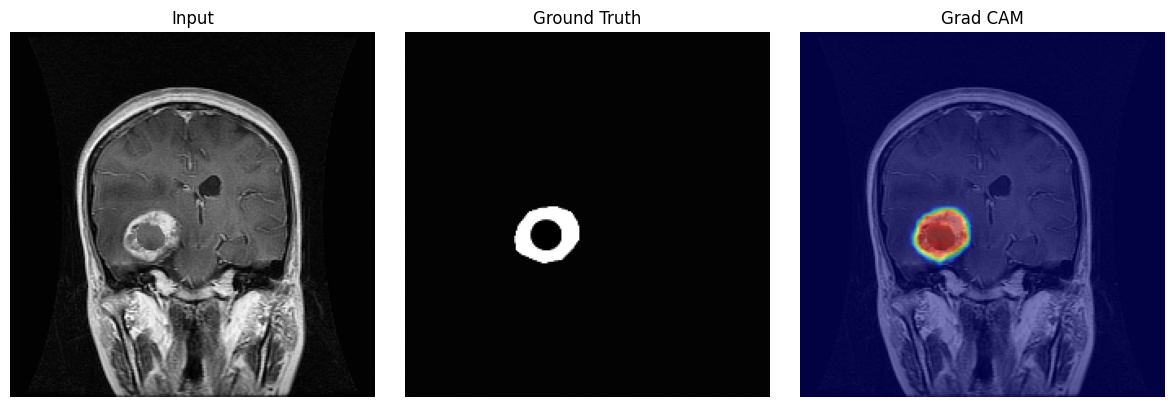


📊 INPUT STATISTICS
Ground Truth Shape   : (224, 224)
Gradient Max         : 1.000000
Gradient Min         : 0.000000
Gradient Shape       : (224, 224)
Ground Truth Max     : 1.000000
Ground Truth Min     : 0.000000

📊 EVALUATION METRICS
IoU             : 0.4660
Coverage        : 0.6358
Focus           : 0.9978
Final Score     : 0.6999


In [ ]:
img = cv2.imread(r"enh_17.png", 0)
gt_mask = cv2.imread(r"enh_17_mask.png", 0)

img = cv2.resize(img, (img_size, img_size))
img = np.expand_dims(img, -1)
img = img/img.max()

gt_mask = cv2.resize(gt_mask, (img_size, img_size))
gt_mask = np.expand_dims(gt_mask, -1)
gt_mask = gt_mask/gt_mask.max()

gt_cls = 0

im = img*255
im = im.astype(np.uint8)
im = cv2.cvtColor(im, cv2.COLOR_GRAY2BGR)
grads, overlayed = plot_gradcam(im, model)

# predict(img, gt_mask, gt_cls)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(img, cmap='gray')
axes[0].set_title("Input")
axes[0].axis("off")

axes[1].imshow(gt_mask, cmap='gray')
axes[1].set_title("Ground Truth")
axes[1].axis("off")

axes[2].imshow(overlayed)
axes[2].set_title("Grad CAM")
axes[2].axis("off")

plt.tight_layout()
plt.show()

metric = get_metrics(grads, gt_mask)

## Bad Case - Donut

🔍 Computing Seg-Grad-CAM for layer: up4_mhsa_reshape_back


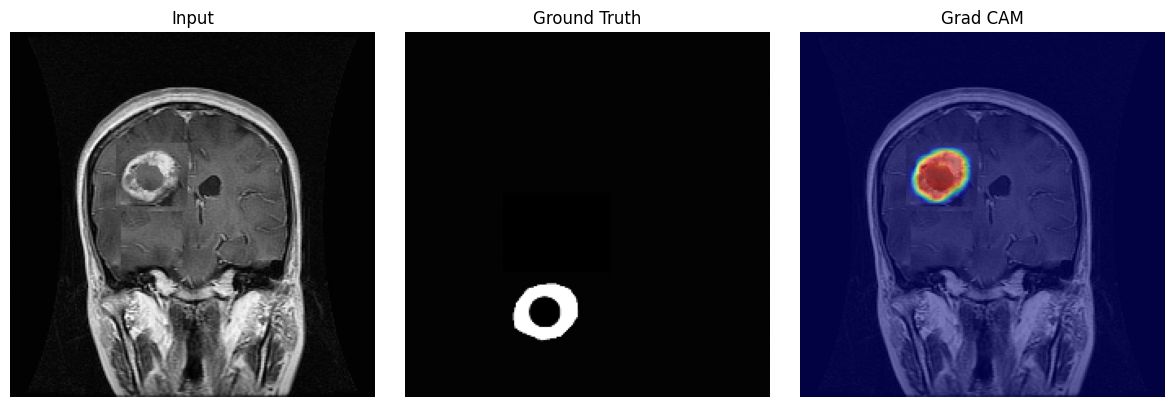


📊 INPUT STATISTICS
Ground Truth Shape   : (224, 224)
Gradient Max         : 1.000000
Gradient Min         : 0.000000
Gradient Shape       : (224, 224)
Ground Truth Max     : 1.000000
Ground Truth Min     : 0.000000

📊 EVALUATION METRICS
IoU             : 0.0000
Coverage        : 0.0000
Focus           : 0.3815
Final Score     : 0.1272


In [ ]:
img = cv2.imread(r"enh_18.png", 0)
gt_mask = cv2.imread(r"enh_18_mask.png", 0)

img = cv2.resize(img, (img_size, img_size))
img = np.expand_dims(img, -1)
img = img/img.max()

gt_mask = cv2.resize(gt_mask, (img_size, img_size))
gt_mask = np.expand_dims(gt_mask, -1)
gt_mask = gt_mask/gt_mask.max()

gt_cls = 0

im = img*255
im = im.astype(np.uint8)
im = cv2.cvtColor(im, cv2.COLOR_GRAY2BGR)
grads, overlayed = plot_gradcam(im, model)

# predict(img, gt_mask, gt_cls)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(img, cmap='gray')
axes[0].set_title("Input")
axes[0].axis("off")

axes[1].imshow(gt_mask, cmap='gray')
axes[1].set_title("Ground Truth")
axes[1].axis("off")

axes[2].imshow(overlayed)
axes[2].set_title("Grad CAM")
axes[2].axis("off")

plt.tight_layout()
plt.show()

metric = get_metrics(grads, gt_mask)